# Bootstrap

## ¿Qué es bootstrap?
Bootstrap es una técnica de **remuestreo con reposición**.

## ¿Cómo funciona?
Tomamos muchas muestras de la muestra original, permitiendo que se repitan observaciones.

## ¿Para qué sirve?
- Estimar la variabilidad de un estadístico
- Construir intervalos de confianza
- Analizar incertidumbre sin depender tanto de fórmulas teóricas

## Idea importante
Bootstrap no crea datos nuevos. Reutiliza la información de la muestra original para simular cómo variarían los resultados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
penguins = sns.load_dataset("penguins").dropna()

# Tomamos una muestra original
muestra = penguins.sample(n=60, random_state=42)

bootstrap_means = []

for _ in range(2000):
    bootstrap_sample = muestra.sample(n=len(muestra), replace=True)
    bootstrap_means.append(bootstrap_sample["body_mass_g"].mean())

In [3]:
bootstrap_means = pd.Series(bootstrap_means)
bootstrap_means.head()

,0
0,4038.333333
1,4054.166667
2,4170.000000
3,4182.083333
4,4131.666667


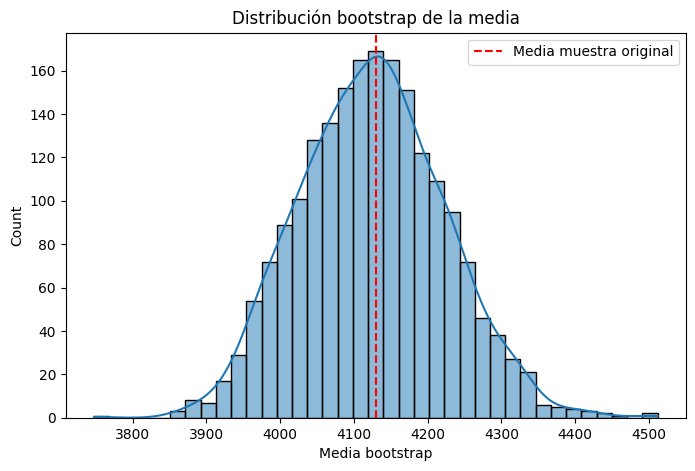

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(bootstrap_means, kde=True)
plt.axvline(muestra["body_mass_g"].mean(), color="red", linestyle="--", label="Media muestra original")
plt.title("Distribución bootstrap de la media")
plt.xlabel("Media bootstrap")
plt.legend()
plt.show()

In [5]:
print("Media muestra original:", round(muestra["body_mass_g"].mean(), 2))
print("Media bootstrap promedio:", round(bootstrap_means.mean(), 2))
print("Desviación de bootstrap:", round(bootstrap_means.std(), 2))

Media muestra original: 4129.58
Media bootstrap promedio: 4124.65
Desviación de bootstrap: 98.2
